# CPLICE Project Walkthrough  
## Pseudo-labeling the UCI Mushroom (Agaricus–Lepiota) dataset

This notebook demonstrates how to use the main components of the **CPLICE project** on a fully categorical classification problem.

The workflow covers:

- loading and preparing the Mushroom dataset,
- selecting representative initially labeled objects,
- computing a reusable categorical distance matrix,
- running CPLICE,
- running competitive pseudo-labeling methods,
- evaluating predictions with external and internal metrics,
- comparing results and saving experiment outputs.

The notebook assumes that it is executed from the **root directory of the project**, where the `algorithms/` and `evaluation/` packages are available.

## 1. Experiment setup

The full Mushroom dataset contains 8,124 observations. A dense pairwise distance matrix grows quadratically, so the notebook uses a configurable stratified subset by default.

Set `MAX_ROWS = None` to run the complete dataset.

In [1]:
from __future__ import annotations

import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder

from ucimlrepo import fetch_ucirepo

from algorithms.competitive.knn_labeling import KNNLabeling
from algorithms.competitive.label_spreading import LabelSpreadingLabeling
from algorithms.competitive.model_based_labeling import ModelBasedLabeling
from algorithms.cplice.cplice import CPLICELabeling
from algorithms.cplice.find_representativeness import (
    select_representatives_by_centroid_contrast,
    select_representatives_by_medoid,
    select_representatives_by_subclustering,
)
from algorithms.cplice.object_distances import compute_distance_matrix
from evaluation.external_metrics import evaluate_external_labels
from evaluation.metrics import CPLICEClusteringEvaluator

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

CACHE_DIR = Path("cache")
RESULTS_DIR = Path("results")
CACHE_DIR.mkdir(exist_ok=True)
RESULTS_DIR.mkdir(exist_ok=True)


In [18]:
# Dataset size
MAX_ROWS: int | None = 8000

# Initial labeled objects
REPRESENTATIVE_METHOD = "centroid_contrast"
INITIAL_OBJECTS_PER_CLASS = 20
COMPETING_SIMILARITY = "mean"

# CPLICE distance and expansion
DISTANCE_METRIC = "s2"
CPLICE_STRATEGY = "outside_mean"
EXPANSION_RATE = 0.03

# Distance matrix storage
DISTANCE_DTYPE = np.float32
USE_MEMMAP = True
WORKING_MEMORY_MB = 256.0

# Competitive methods
MODEL_CONFIDENCE_CUTOFF = 0.95
MODEL_MAX_ITERATIONS = 15
LABEL_SPREADING_NEIGHBORS = 15


### Main configuration choices

`DISTANCE_METRIC` may be changed to any metric supported by the project, for example:

```python
"overlap", "hamming", "eskin", "iof", "lin", "s2"
```

`CPLICE_STRATEGY` controls how a candidate is compared with its provisional cluster. For example:

```python
"nearest", "mean", "farthest", "outside_mean"
```

The exact strategy names should match the names used by `CPLICELabeling` in the project.

## 2. Load the Mushroom dataset

The target contains two classes:

- `e`: edible,
- `p`: poisonous.

All predictors are categorical. Missing values are preserved as an explicit category.

In [19]:
mushroom = fetch_ucirepo(id=73)

X_full = mushroom.data.features.copy()
y_full = mushroom.data.targets.iloc[:, 0].copy()

X_full = (
    X_full.astype("object")
    .where(X_full.notna(), "__MISSING__")
    .astype(str)
)

y_full = (
    y_full.astype(str)
    .replace({"e": "edible", "p": "poisonous"})
    .rename("class")
)

print("Full feature matrix:", X_full.shape)
display(y_full.value_counts().rename("count").to_frame())


Full feature matrix: (8124, 22)


,count
class,
edible,4208
poisonous,3916


## 3. Create a reproducible experimental subset

The subset is stratified, so the original class proportions are approximately preserved.

In [20]:
if MAX_ROWS is not None and MAX_ROWS < len(X_full):
    full_indices = np.arange(len(X_full))

    selected_indices, _ = train_test_split(
        full_indices,
        train_size=MAX_ROWS,
        stratify=y_full,
        random_state=RANDOM_STATE,
    )
    selected_indices = np.sort(selected_indices)

    X = X_full.iloc[selected_indices].reset_index(drop=True)
    y = y_full.iloc[selected_indices].reset_index(drop=True)
else:
    X = X_full.reset_index(drop=True)
    y = y_full.reset_index(drop=True)

print("Experimental feature matrix:", X.shape)
display(y.value_counts().rename("count").to_frame())


Experimental feature matrix: (8000, 22)


,count
class,
edible,4144
poisonous,3856


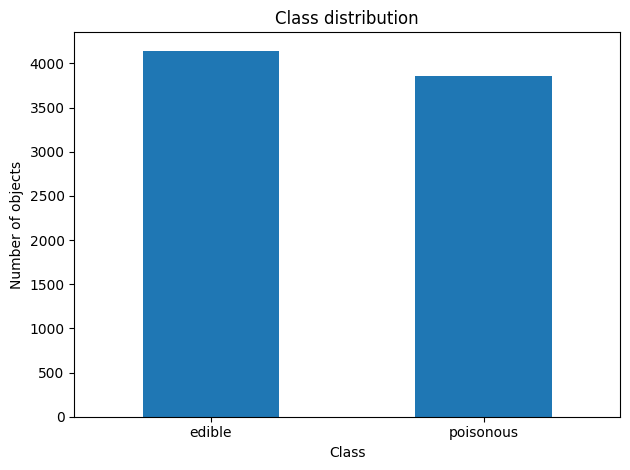

In [21]:
ax = y.value_counts().sort_index().plot(
    kind="bar",
    title="Class distribution",
    rot=0,
)
ax.set_xlabel("Class")
ax.set_ylabel("Number of objects")
plt.tight_layout()
plt.show()


## 4. Select initially labeled representatives

The project provides several research strategies:

### Centroid contrast
Selects objects that are similar to the mode of their own class and dissimilar to competing class modes.

### Medoid centrality
Selects objects with the smallest total within-class categorical distance.

### Subcluster-balanced selection
Runs K-Modes inside each class and selects central objects from different discovered subclusters.

In a real annotation study, this step represents the objects presented to an expert for labeling. Here, the known Mushroom labels are used to simulate that process.

In [22]:
def select_initial_representatives(
    data: pd.DataFrame,
    labels: pd.Series,
    method: str,
    number_per_class: int,
) -> dict[object, list[int]]:
    feature_values = data.to_numpy(dtype=object)
    class_values = labels.to_numpy(dtype=object)

    if method == "centroid_contrast":
        return select_representatives_by_centroid_contrast(
            data=feature_values,
            class_labels=class_values,
            number_per_class=number_per_class,
            competing_similarity=COMPETING_SIMILARITY,
        )

    if method == "medoid":
        return select_representatives_by_medoid(
            data=feature_values,
            class_labels=class_values,
            number_per_class=number_per_class,
        )

    if method == "subclustering":
        return select_representatives_by_subclustering(
            data=feature_values,
            class_labels=class_values,
            number_per_class=number_per_class,
            maximum_clusters=10,
            random_state=RANDOM_STATE,
        )

    raise ValueError(f"Unsupported representative method: {method!r}")


initial_clusters = select_initial_representatives(
    data=X,
    labels=y,
    method=REPRESENTATIVE_METHOD,
    number_per_class=INITIAL_OBJECTS_PER_CLASS,
)

initial_clusters = {
    label: [int(index) for index in indices]
    for label, indices in initial_clusters.items()
}

initial_indices = np.sort(
    np.concatenate(
        [
            np.asarray(indices, dtype=int)
            for indices in initial_clusters.values()
        ]
    )
)

unlabeled_indices = np.setdiff1d(
    np.arange(len(X)),
    initial_indices,
    assume_unique=True,
)

print("Representative method:", REPRESENTATIVE_METHOD)
print("Initial objects by class:")
print({label: len(indices) for label, indices in initial_clusters.items()})
print("Total initially labeled:", len(initial_indices))
print("Objects left for pseudo-labeling:", len(unlabeled_indices))


Representative method: centroid_contrast
Initial objects by class:
{'poisonous': 20, 'edible': 20}
Total initially labeled: 40
Objects left for pseudo-labeling: 7960


In [23]:
initial_objects = X.iloc[initial_indices].copy()
initial_objects.insert(
    0,
    "class",
    y.iloc[initial_indices].to_numpy(),
)
initial_objects.insert(
    0,
    "row_index",
    initial_indices,
)

display(initial_objects.head(10))


,row_index,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
1572,1572,edible,x,f,g,t,n,f,c,b,...,s,w,w,p,w,o,p,n,v,d
1829,1829,edible,x,f,e,t,n,f,c,b,...,s,g,g,p,w,o,p,n,v,d
1835,1835,edible,x,f,g,t,n,f,c,b,...,s,p,w,p,w,o,p,n,y,d
1861,1861,edible,x,f,n,t,n,f,c,b,...,s,w,g,p,w,o,p,n,v,d
1879,1879,edible,x,f,n,t,n,f,c,b,...,s,w,p,p,w,o,p,n,v,d
1903,1903,edible,x,f,n,t,n,f,c,b,...,s,g,w,p,w,o,p,n,v,d
1921,1921,edible,x,f,g,t,n,f,c,b,...,s,p,p,p,w,o,p,n,v,d
1966,1966,edible,x,f,n,t,n,f,c,b,...,s,p,g,p,w,o,p,n,y,d
2011,2011,edible,f,f,g,t,n,f,c,b,...,s,p,w,p,w,o,p,n,y,d
2042,2042,edible,x,f,g,t,n,f,c,b,...,s,p,p,p,w,o,p,n,y,d


## 5. Compute a reusable categorical distance matrix

The matrix is computed once and reused by:

- CPLICE,
- KNN,
- internal clustering metrics.

This is especially important for more expensive measures such as Lin, IOF, or S2.

In [24]:
matrix_path = (
    CACHE_DIR
    / (
        f"mushroom_{len(X)}_"
        f"{DISTANCE_METRIC}_{np.dtype(DISTANCE_DTYPE).name}.dat"
    )
)

matrix_start = time.perf_counter()

distance_matrix = compute_distance_matrix(
    data=X,
    metric=DISTANCE_METRIC,
    working_memory_mb=WORKING_MEMORY_MB,
    dtype=DISTANCE_DTYPE,
    output_path=matrix_path if USE_MEMMAP else None,
)

matrix_runtime = time.perf_counter() - matrix_start

print("Distance metric:", DISTANCE_METRIC)
print("Matrix shape:", distance_matrix.shape)
print("Matrix dtype:", distance_matrix.dtype)
print(f"Matrix size: {distance_matrix.nbytes / 1024**2:.2f} MB")
print(f"Computation time: {matrix_runtime:.2f} seconds")


Distance metric: s2
Matrix shape: (8000, 8000)
Matrix dtype: float32
Matrix size: 244.14 MB
Computation time: 15.59 seconds


## 6. Run CPLICE

CPLICE receives:

- the original categorical DataFrame,
- the selected metric,
- a cluster scoring strategy,
- the reusable distance matrix,
- indices of initially labeled representatives.

The output contains one pseudo-label for every row in `X`.

In [27]:
cplice_start = time.perf_counter()

cplice = CPLICELabeling(
    df=X,
    metric=DISTANCE_METRIC,
    strategy=CPLICE_STRATEGY,
    distance_matrix=distance_matrix,
)

cplice_labels_all = np.asarray(
    cplice.label_data(
        initial_clusters=initial_clusters,
        expansion_rate=0.1,
    ),
    dtype=object,
)

cplice_runtime = time.perf_counter() - cplice_start
cplice_predictions = cplice_labels_all[unlabeled_indices]

print(f"CPLICE runtime: {cplice_runtime:.2f} seconds")
display(
    pd.Series(cplice_predictions, name="prediction")
    .value_counts()
    .to_frame()
)


CPLICE runtime: 151.48 seconds


,count
prediction,
edible,4810
poisonous,3150


## 7. Run the 1-NN competitive baseline

KNN uses the same initially labeled representatives and the same distance matrix. This creates a direct comparison between one-step nearest-neighbor propagation and iterative CPLICE expansion.

In [28]:
knn_start = time.perf_counter()

knn = KNNLabeling(
    df=X,
    metric=DISTANCE_METRIC,
    distance_matrix=distance_matrix,
)

knn_labels_all = np.asarray(
    knn.label_data(initial_clusters),
    dtype=object,
)

knn_runtime = time.perf_counter() - knn_start
knn_predictions = knn_labels_all[unlabeled_indices]

print(f"KNN runtime: {knn_runtime:.2f} seconds")


KNN runtime: 0.24 seconds


## 8. Prepare encoded data for model-based methods

`ModelBasedLabeling` and `LabelSpreadingLabeling` use numeric feature matrices. The categorical Mushroom features are therefore one-hot encoded.

The encoder is fitted without using class labels.

In [29]:
encoder = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=False,
    dtype=np.float32,
)

X_encoded = encoder.fit_transform(X)

labeled_rows_encoded = {
    label: X_encoded[np.asarray(indices, dtype=int)]
    for label, indices in initial_clusters.items()
}

X_unlabeled_encoded = X_encoded[unlabeled_indices]
y_unlabeled = y.iloc[unlabeled_indices].to_numpy(dtype=object)

print("Encoded feature matrix:", X_encoded.shape)


Encoded feature matrix: (8000, 117)


## 9. Run model-based iterative pseudo-labeling

The model-based wrapper accepts an arbitrary classifier implementing `fit` and `predict`. Models exposing `predict_proba` or `decision_function` can also support confidence-based iterative expansion.

This example uses a random forest.

In [30]:
classifier = RandomForestClassifier(
    n_estimators=300,
    class_weight="balanced",
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

model_start = time.perf_counter()

model_based = ModelBasedLabeling(X_unlabeled_encoded)

model_predictions, model_confidences = model_based.label_data(
    labeled_data=labeled_rows_encoded,
    model=classifier,
    confidence_cutoff=MODEL_CONFIDENCE_CUTOFF,
    max_iterations=MODEL_MAX_ITERATIONS,
)

model_runtime = time.perf_counter() - model_start

print(f"Model-based runtime: {model_runtime:.2f} seconds")
print(f"Mean confidence: {np.nanmean(model_confidences):.4f}")


Model-based runtime: 1.85 seconds
Mean confidence: 0.7493


## 10. Run graph-based Label Spreading

Label Spreading constructs a graph over labeled and unlabeled objects and propagates labels through the graph.

The wrapper preserves the original class names and exposes:

- predicted labels,
- maximum confidence,
- full class distributions,
- fitted model details.

In [31]:
spreading_start = time.perf_counter()

label_spreading = LabelSpreadingLabeling(X_unlabeled_encoded)

spreading_predictions, spreading_confidences = (
    label_spreading.label_data(
        labeled_data=labeled_rows_encoded,
        kernel="knn",
        n_neighbors=LABEL_SPREADING_NEIGHBORS,
        alpha=0.2,
        max_iterations=30,
        tol=1e-3,
        n_jobs=-1,
    )
)

spreading_runtime = time.perf_counter() - spreading_start

print(f"Label Spreading runtime: {spreading_runtime:.2f} seconds")
print(f"Mean confidence: {spreading_confidences.mean():.4f}")
print(
    "Effective number of neighbors:",
    label_spreading.effective_n_neighbors_,
)


Label Spreading runtime: 0.12 seconds
Mean confidence: 0.4215
Effective number of neighbors: 15


## 11. External evaluation

The initially labeled representatives are excluded from the main evaluation. This avoids measuring performance on objects whose labels were supplied to the algorithms.

The external evaluator reports two groups:

### Classification metrics
Accuracy, macro precision, macro recall, macro F1, Jaccard, MCC, Cohen’s kappa, and AUC when continuous scores are available.

### Partition metrics
ARI, NMI, FMI, variation of information, homogeneity, completeness, V-measure, and conditional cluster entropy.

In [32]:
predictions_by_method = {
    "CPLICE": cplice_predictions,
    "KNN": knn_predictions,
    "ModelBased-RF": np.asarray(model_predictions, dtype=object),
    "LabelSpreading": np.asarray(
        spreading_predictions,
        dtype=object,
    ),
}

runtime_by_method = {
    "CPLICE": cplice_runtime,
    "KNN": knn_runtime,
    "ModelBased-RF": model_runtime,
    "LabelSpreading": spreading_runtime,
}

external_reports = {}
external_rows = []

for method_name, predictions in predictions_by_method.items():
    if method_name == "LabelSpreading":
        report = evaluate_external_labels(
            y_true=y_unlabeled,
            y_pred=predictions,
            y_score=label_spreading.probabilities_,
            score_labels=label_spreading.classes_,
        )
    else:
        report = evaluate_external_labels(
            y_true=y_unlabeled,
            y_pred=predictions,
        )

    external_reports[method_name] = report

    external_rows.append(
        {
            "method": method_name,
            "runtime_seconds": runtime_by_method[method_name],
            **report.classification,
            **report.clustering,
        }
    )

external_results = (
    pd.DataFrame(external_rows)
    .set_index("method")
    .sort_values("f1_macro", ascending=False)
)

display(external_results.round(5))


,runtime_seconds,accuracy,precision_macro,recall_macro,f1_macro,jaccard_macro,hamming_loss,matthews_corrcoef,cohens_kappa,roc_auc,adjusted_rand,fowlkes_mallows,normalized_mutual_information,variation_of_information,homogeneity,completeness,v_measure,conditional_cluster_entropy
method,,,,,,,,,,,,,,,,,,
CPLICE,151.48155,0.88492,0.89848,0.88165,0.88318,0.79109,0.11508,0.77995,0.76810,NaN,0.59260,0.80092,0.52556,0.64701,0.51750,0.53388,0.52556,0.33413
ModelBased-RF,1.84713,0.86018,0.86657,0.85777,0.85883,0.75284,0.13982,0.72428,0.71873,NaN,0.51883,0.76261,0.42925,0.78361,0.42551,0.43305,0.42925,0.39783
KNN,0.23631,0.81922,0.82309,0.81709,0.81779,0.69206,0.18078,0.64015,0.63659,NaN,0.40752,0.70686,0.32341,0.93077,0.32123,0.32561,0.32341,0.47004
LabelSpreading,0.11534,0.69246,0.80522,0.70320,0.66802,0.50842,0.30754,0.49808,0.39754,0.7032,0.14772,0.64192,0.27288,0.87777,0.23785,0.32001,0.27288,0.52779


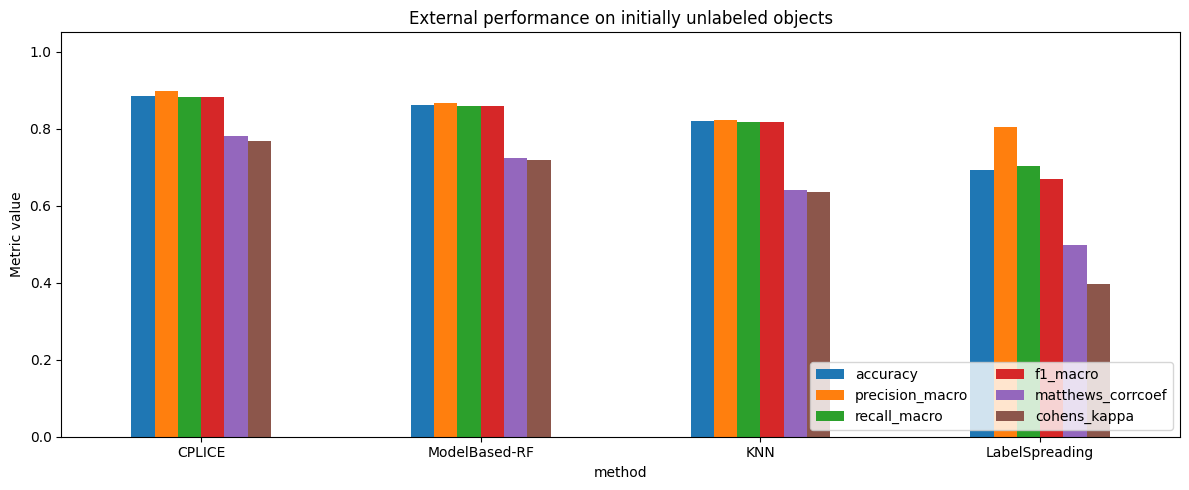

In [33]:
classification_metrics = [
    "accuracy",
    "precision_macro",
    "recall_macro",
    "f1_macro",
    "matthews_corrcoef",
    "cohens_kappa",
]

ax = external_results[classification_metrics].plot(
    kind="bar",
    figsize=(12, 5),
    ylim=(0, 1.05),
    rot=0,
    title="External performance on initially unlabeled objects",
)
ax.set_ylabel("Metric value")
ax.legend(loc="lower right", ncol=2)
plt.tight_layout()
plt.show()


## 12. Internal evaluation in the CPLICE distance geometry

The internal evaluator receives the same pairwise distance matrix used by CPLICE. This keeps the evaluation geometry consistent across methods.

Recommended internal measures include:

- silhouette,
- Dunn index,
- distance-based pseudo-F,
- medoid Davies–Bouldin,
- within-cluster dispersion,
- between-medoid separation,
- normalized categorical entropy.

In [34]:
unlabeled_distance_matrix = distance_matrix[
    np.ix_(unlabeled_indices, unlabeled_indices)
]

unlabeled_categorical_data = X.iloc[
    unlabeled_indices
].to_numpy(dtype=object)

internal_rows = []

for method_name, predictions in predictions_by_method.items():
    evaluator = CPLICEClusteringEvaluator(
        labels=predictions,
        distance_matrix=unlabeled_distance_matrix,
        categorical_data=unlabeled_categorical_data,
    )

    report = evaluator.evaluate(
        include_categorical_metrics=True,
        include_experimental_metrics=False,
    )

    internal_rows.append(
        {
            "method": method_name,
            **report.values(),
        }
    )

internal_results = (
    pd.DataFrame(internal_rows)
    .set_index("method")
)

display(internal_results.round(5))


,silhouette,dunn,distance_pseudo_f,medoid_davies_bouldin,within_dispersion,between_medoid_separation,dispersion_separation_ratio,normalized_entropy,mode_mismatch_rate,mode_separation,mode_mismatch_separation_ratio
method,,,,,,,,,,,
CPLICE,0.15494,0.05680,1326.33854,1.48063,0.77032,0.91111,0.84547,0.52327,0.35144,0.59091,0.59474
KNN,0.13977,0.05710,1164.67250,1.43010,0.77296,0.95300,0.81109,0.54274,0.35874,0.63636,0.56374
ModelBased-RF,0.14534,0.06244,1226.15479,1.49000,0.77185,0.91206,0.84627,0.53261,0.35420,0.54545,0.64937
LabelSpreading,0.11018,0.40074,1007.55528,1.37817,0.81436,0.94919,0.85795,0.55393,0.38592,0.54545,0.70753


## 13. Inspect class distributions inside predicted groups

This view helps identify whether one predicted class contains substantial contamination from the other true class.

In [35]:
for method_name, report in external_reports.items():
    print(f"\n{method_name}")
    display(pd.DataFrame(report.distribution).fillna(0).astype(int))



CPLICE


,edible,poisonous
poisonous,801,3035
edible,4009,115



KNN


,edible,poisonous
poisonous,928,2908
edible,3613,511



ModelBased-RF


,edible,poisonous
poisonous,801,3035
edible,3812,312



LabelSpreading


,poisonous,edible
poisonous,3836,0
edible,2448,1676


## 14. Inspect confidence distributions

Only the probabilistic competitive methods expose confidence values.

,count,mean,std,min,25%,50%,75%,max
ModelBased-RF,7960.0,0.74933,0.15502,0.50333,0.61667,0.73333,0.89,1.0
LabelSpreading,7960.0,0.42148,0.49383,0.00000,0.00000,0.00000,1.00,1.0


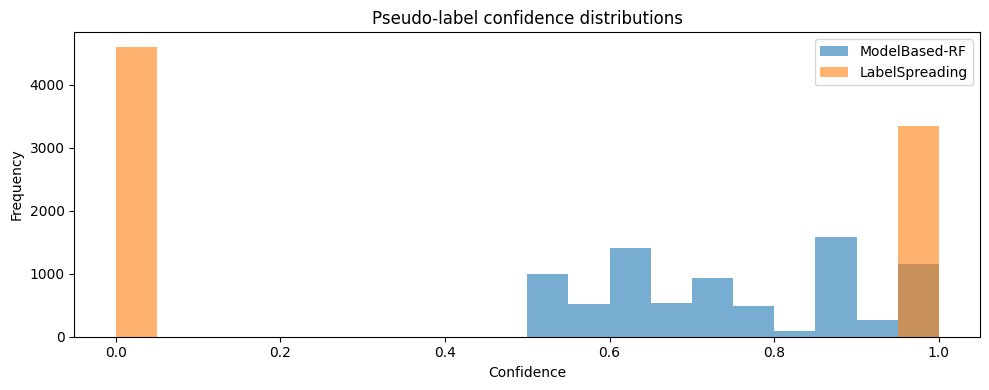

In [36]:
confidence_frame = pd.DataFrame(
    {
        "ModelBased-RF": model_confidences,
        "LabelSpreading": spreading_confidences,
    }
)

display(confidence_frame.describe().T.round(5))

confidence_frame.plot(
    kind="hist",
    bins=20,
    alpha=0.6,
    figsize=(10, 4),
    title="Pseudo-label confidence distributions",
)
plt.xlabel("Confidence")
plt.tight_layout()
plt.show()


## 15. Compare individual predictions

The table keeps original row indices, true labels, predictions, and confidence values. It can be used for error analysis or manual inspection of difficult objects.

In [37]:
prediction_table = pd.DataFrame(
    {
        "row_index": unlabeled_indices,
        "true_label": y_unlabeled,
        "CPLICE": cplice_predictions,
        "KNN": knn_predictions,
        "ModelBased-RF": model_predictions,
        "ModelBased-RF-confidence": model_confidences,
        "LabelSpreading": spreading_predictions,
        "LabelSpreading-confidence": spreading_confidences,
    }
)

display(prediction_table.head(20))


,row_index,true_label,CPLICE,KNN,ModelBased-RF,ModelBased-RF-confidence,LabelSpreading,LabelSpreading-confidence
0,0,poisonous,edible,edible,edible,0.646667,poisonous,0.0
1,1,edible,edible,edible,edible,0.733333,poisonous,0.0
2,2,edible,edible,edible,edible,0.733333,poisonous,0.0
3,3,poisonous,edible,edible,edible,0.646667,poisonous,0.0
4,4,edible,edible,edible,edible,0.603333,poisonous,0.0
5,5,edible,edible,edible,edible,0.736667,poisonous,0.0
6,6,edible,edible,edible,edible,0.736667,poisonous,0.0
7,7,edible,edible,edible,edible,0.733333,poisonous,0.0
8,8,poisonous,edible,edible,edible,0.640000,poisonous,0.0
9,9,edible,edible,edible,edible,0.736667,poisonous,0.0


In [38]:
cplice_errors = prediction_table[
    prediction_table["CPLICE"]
    != prediction_table["true_label"]
]

print("CPLICE errors:", len(cplice_errors))
display(cplice_errors.head(20))


CPLICE errors: 916


,row_index,true_label,CPLICE,KNN,ModelBased-RF,ModelBased-RF-confidence,LabelSpreading,LabelSpreading-confidence
0,0,poisonous,edible,edible,edible,0.646667,poisonous,0.0
3,3,poisonous,edible,edible,edible,0.646667,poisonous,0.0
8,8,poisonous,edible,edible,edible,0.640000,poisonous,0.0
13,13,poisonous,edible,edible,edible,0.636667,poisonous,0.0
17,17,poisonous,edible,edible,edible,0.646667,poisonous,0.0
18,18,poisonous,edible,edible,edible,0.643333,poisonous,0.0
19,19,poisonous,edible,edible,edible,0.643333,poisonous,0.0
21,21,poisonous,edible,edible,edible,0.636667,poisonous,0.0
25,25,poisonous,edible,edible,edible,0.633333,poisonous,0.0
36,36,poisonous,edible,edible,edible,0.643333,poisonous,0.0


## 16. Save experiment outputs

The notebook stores:

- external metrics,
- internal metrics,
- row-level predictions,
- initially labeled representatives.

In [39]:
external_results.to_csv(
    RESULTS_DIR / "mushroom_external_metrics.csv"
)
internal_results.to_csv(
    RESULTS_DIR / "mushroom_internal_metrics.csv"
)
prediction_table.to_csv(
    RESULTS_DIR / "mushroom_predictions.csv",
    index=False,
)
initial_objects.to_csv(
    RESULTS_DIR / "mushroom_initial_representatives.csv",
    index=False,
)

print("Saved experiment outputs to:", RESULTS_DIR.resolve())


Saved experiment outputs to: C:\Users\imagi\PycharmProjects\cplice\example\results


## 17. Suggested research extensions

The same workflow can be repeated over a parameter grid.

```python
representative_methods = [
    "centroid_contrast",
    "medoid",
    "subclustering",
]

initial_objects_per_class = [5, 10, 20, 50]

distance_metrics = [
    "overlap",
    "eskin",
    "iof",
    "lin",
    "s2",
]

cplice_strategies = [
    "nearest",
    "mean",
    "farthest",
    "outside_mean",
]
```

For publication-quality experiments, record separately:

- representative selection method,
- number of initially labeled objects,
- distance metric,
- CPLICE strategy,
- expansion rate,
- matrix computation time,
- pseudo-labeling runtime,
- external metrics,
- internal metrics,
- random seed,
- matrix dtype and storage method.

The initial representative objects should remain fixed when comparing pseudo-labeling algorithms within the same experimental run.